# Objective
To analyze the Titanic dataset and identify the key factors that influenced passenger survival, using exploratory data analysis and machine learning techniques to build a predictive model.

## Understanding The Data

In [100]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [101]:
df = pd.read_csv('tested.csv')

In [102]:
df.shape

(418, 12)

In [103]:
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
43,935,1,2,"Corbett, Mrs. Walter H (Irene Colvin)",female,30.0,0,0,237249,13.0000,NaN,S
205,1097,0,1,"Omont, Mr. Alfred Fernand",male,NaN,0,0,F.C. 12998,25.7417,NaN,C
332,1224,0,3,"Thomas, Mr. Tannous",male,NaN,0,0,2684,7.2250,NaN,C
245,1137,0,1,"Kenyon, Mr. Frederick R",male,41.0,1,0,17464,51.8625,D21,S
12,904,1,1,"Snyder, Mrs. John Pillsbury (Nelle Stevenson)",female,23.0,1,0,21228,82.2667,B45,S
65,957,1,2,"Corey, Mrs. Percy C (Mary Phyllis Elizabeth Mi...",female,NaN,0,0,F.C.C. 13534,21.0000,NaN,S
101,993,0,2,"Weisz, Mr. Leopold",male,27.0,1,0,228414,26.0000,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
296,1188,1,2,"Laroche, Miss. Louise",female,1.0,1,2,SC/Paris 2123,41.5792,NaN,C
135,1027,0,3,"Carlsson, Mr. Carl Robert",male,24.0,0,0,350409,7.8542,NaN,S


In [104]:
df = df.drop(columns =['PassengerId','Name'])

In [105]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,male,34.5,0,0,330911,7.8292,NaN,Q
1,1,3,female,47.0,1,0,363272,7.0000,NaN,S
2,0,2,male,62.0,0,0,240276,9.6875,NaN,Q
3,0,3,male,27.0,0,0,315154,8.6625,NaN,S
4,1,3,female,22.0,1,1,3101298,12.2875,NaN,S


In [106]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  418 non-null    int64  
 1   Pclass    418 non-null    int64  
 2   Sex       418 non-null    str    
 3   Age       332 non-null    float64
 4   SibSp     418 non-null    int64  
 5   Parch     418 non-null    int64  
 6   Ticket    418 non-null    str    
 7   Fare      417 non-null    float64
 8   Cabin     91 non-null     str    
 9   Embarked  418 non-null    str    
dtypes: float64(2), int64(4), str(4)
memory usage: 32.8 KB


In [107]:
df.isna().sum()

Survived      0
Pclass        0
Sex           0
Age          86
SibSp         0
Parch         0
Ticket        0
Fare          1
Cabin       327
Embarked      0
dtype: int64

In [108]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [109]:
df.drop(columns=['Cabin', 'Ticket'], inplace=True)
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,34.50000,0,0,7.8292,Q
1,1,3,female,47.00000,1,0,7.0000,S
2,0,2,male,62.00000,0,0,9.6875,Q
3,0,3,male,27.00000,0,0,8.6625,S
4,1,3,female,22.00000,1,1,12.2875,S
...,...,...,...,...,...,...,...,...
413,0,3,male,30.27259,0,0,8.0500,S
414,1,1,female,39.00000,0,0,108.9000,C
415,0,3,male,38.50000,0,0,7.2500,S
416,0,3,male,30.27259,0,0,8.0500,S


In [120]:
df.dropna(inplace=True)
df.isna().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

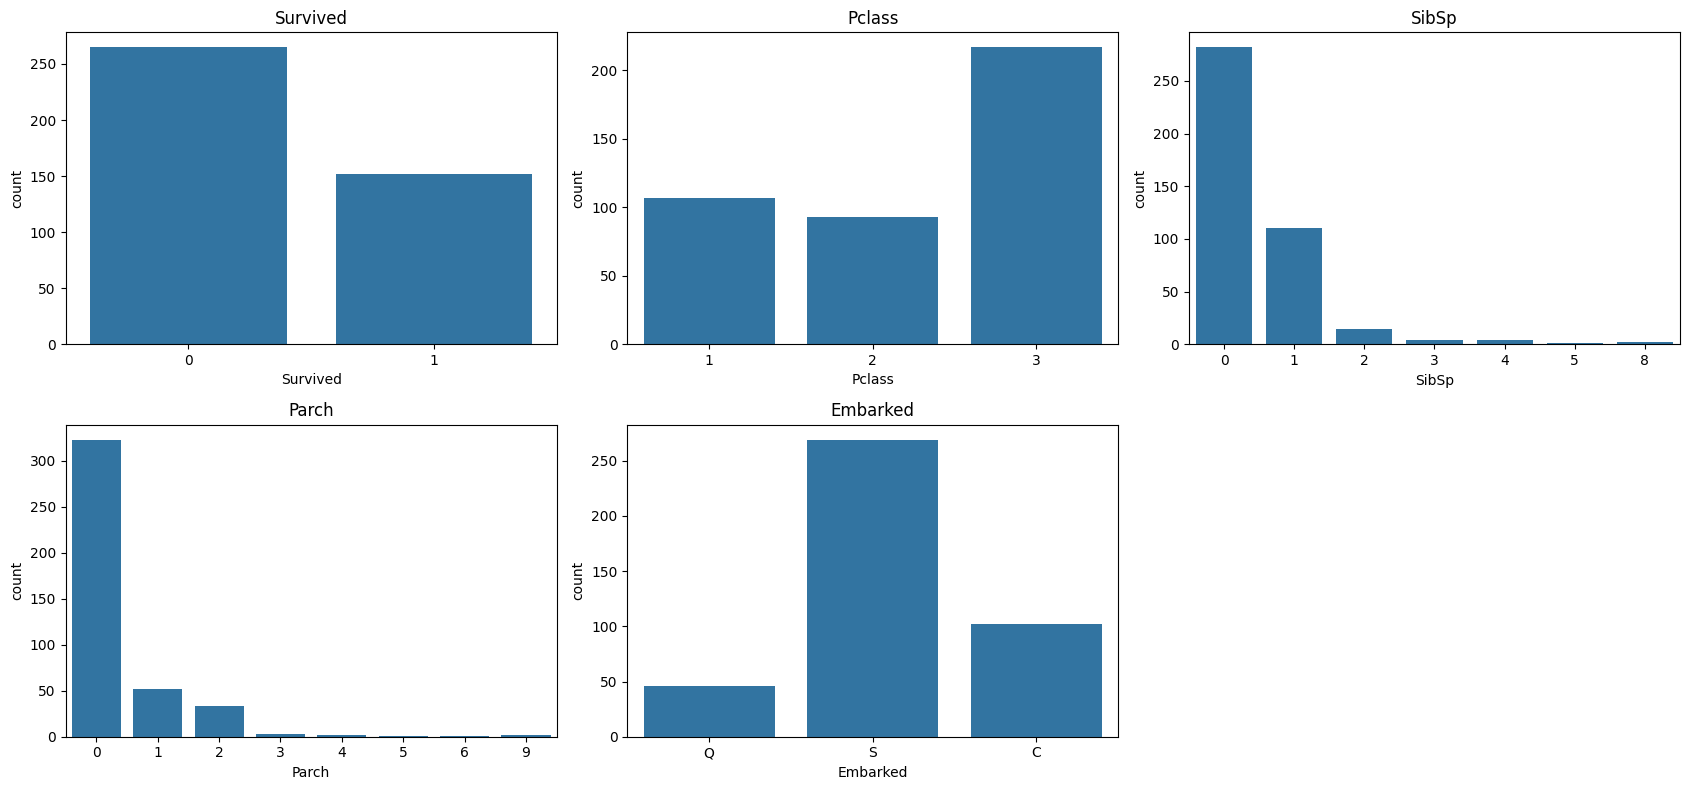

In [111]:
cat_cols = ['Survived', 'Pclass', 'SibSp', 'Parch', 'Embarked']

plt.figure(figsize=(17, 8))

for j, i in enumerate(cat_cols, 1):
    plt.subplot(2, 3, j)
    sns.countplot(x=i, data=df)
    plt.title(i)

plt.tight_layout()
plt.show()


<Axes: xlabel='Survived', ylabel='Age'>

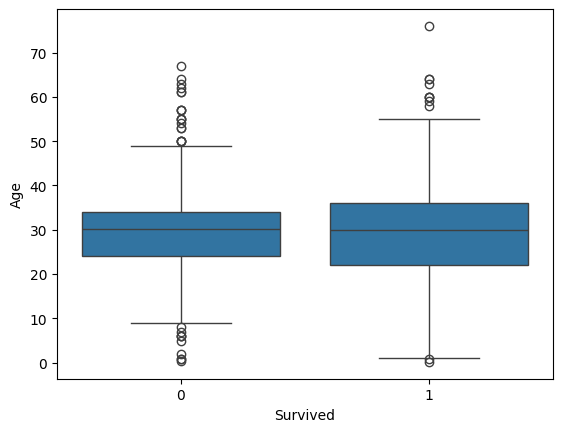

In [112]:
sns.boxplot(x='Survived', y='Age', data=df)

<Axes: xlabel='Survived', ylabel='Fare'>

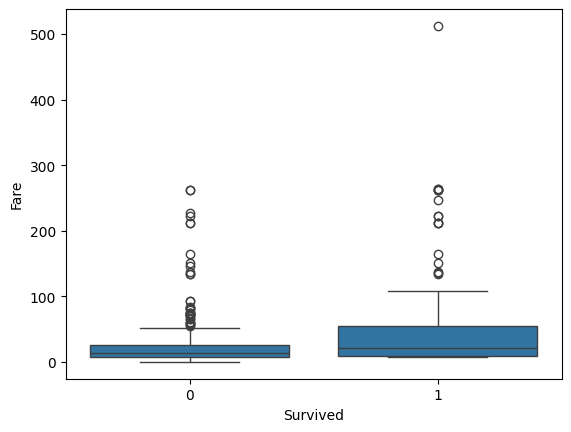

In [113]:
sns.boxplot(x='Survived', y='Fare', data=df)

## 2. Splitting

In [114]:
X = df.drop(columns='Survived')
Y = df['Survived']

In [115]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=42)

# 3. Pre Processing

In [116]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ctr = ColumnTransformer(
    transformers=[
        ('ohe', OneHotEncoder(drop='first'), ['Embarked', 'Sex'])
    ], remainder='passthrough'
)

In [117]:
X_train_transformed = ctr.fit_transform(X_train)
X_test_transformed = ctr.transform(X_test)

## 4. Model Training

In [118]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_transformed, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 5. Evaluation

In [ ]:
from sklearn.metrics import r2_score


y_pred = lr.predict(X_test_transformed)
r2_score(Y_test, y_pred)

1.0